# Mount Drive

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Importing Keras ImageDataGenerator for Data Augmentation in Deep Learning Pipelines
ImageDataGenerator used to generate and modify images automatically during training

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Common transformations it can apply:
# Rotation (e.g., rotate image slightly)
# Zooming in/out
# Shifting (left/right/up/down)
# Flipping (horizontal/vertical)
# Rescaling pixel values

# Defining Image Input Size and Batch Size for Model Training

In [14]:
imgage_size=(150,150)
batch_size=32

# Image Data Augmentation Setup (Training and Testing Generators)

In [15]:
train_datagen=ImageDataGenerator(rescale=1/255,
                                 shear_range=0.2,

                                 )

test_datagen=ImageDataGenerator(rescale=1/255,
                                 shear_range=0.2,
                                 )

# Loading Training and Testing Dataset from Directory (Image Generator Flow Setup)

In [16]:
training_set=train_datagen.flow_from_directory('/content/drive/MyDrive/dataset/training_set',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')


test_set=train_datagen.flow_from_directory('/content/drive/MyDrive/dataset/test_set',
                                               target_size=imgage_size,
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 8011 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# CNN Model Building

In [17]:
model=keras.Sequential(
    [

        keras.layers.Conv2D(32,(3,3), activation='relu',input_shape=(150,150,3)),

        keras.layers.MaxPooling2D((3,3)),
        keras.layers.Conv2D(32,(3,3), activation='relu'),
        keras.layers.MaxPooling2D((3,3)),
        keras.layers.Conv2D(32,(3,3), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu',),
        keras.layers.Dense(1, activation='sigmoid'),

     ]
)

# Model Compilation and Training

In [18]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',metrics=['accuracy']


)


history = model.fit(
    training_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1888s 7s/step - accuracy: 0.5963 - loss: 0.6545 - val_accuracy: 0.6850 - val_loss: 0.5870
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 96s 382ms/step - accuracy: 0.7239 - loss: 0.5454 - val_accuracy: 0.7300 - val_loss: 0.5385
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 367ms/step - accuracy: 0.7709 - loss: 0.4827 - val_accuracy: 0.7545 - val_loss: 0.4927
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 95s 377ms/step - accuracy: 0.7970 - loss: 0.4389 - val_accuracy: 0.7605 - val_loss: 0.5037
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 97s 386ms/step - accuracy: 0.8140 - loss: 0.4024 - val_accuracy: 0.7710 - val_loss: 0.5106
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.8362 - loss: 0.3609 - val_accuracy: 0.7910 - val_loss: 0.4588
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 95s 379ms/step - accuracy: 0.8745 - loss: 0.2981 - val_accuracy: 0.7810 - val_loss: 0.4939
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 97s 387ms/step - accuracy: 0.9035 - loss: 0.

# Model Evaluation on Test Data

In [19]:
test_loss, test_acc = model.evaluate(test_set)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 325ms/step - accuracy: 0.7895 - loss: 0.7050
Test Loss: 0.70500648021698
Test Accuracy: 0.7894999980926514


# Generating Predictions and Extracting True Labels

In [20]:
y_pred = model.predict(test_set)
import numpy as np

y_pred = np.argmax(y_pred, axis=1)
y_true = test_set.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 300ms/step


In [21]:
y_true

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

# Confusion Matrix Visualization

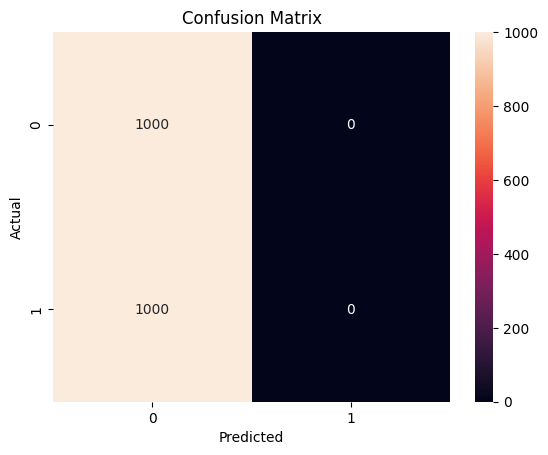

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Model Performance Evaluation Report (Classification Metrics)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67      1000
           1       0.00      0.00      0.00      1000

    accuracy                           0.50      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.25      0.50      0.33      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Training and Validation Accuracy Visualization

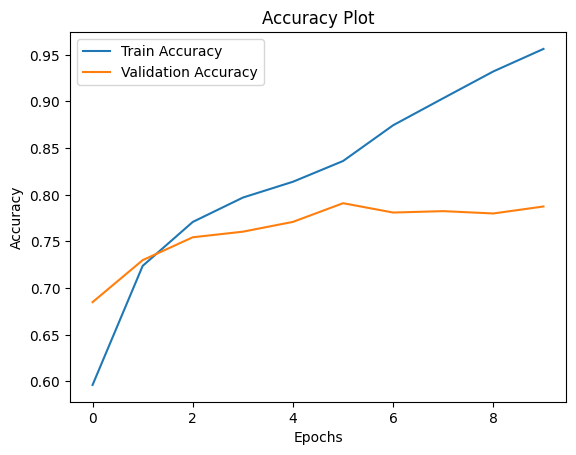

In [24]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Save Model

In [25]:
model.save_weights('cat_dog.weights.h5')